# The full-fidelity aerodynamic pipeline

Launch to hypersonic glide re-entry is not one flow regime, it is five, and no
single method covers them. This notebook is the assembled pipeline and, more
importantly, the **evidence for each piece** — every layer checked against
something that is not another correlation.

| Layer | Method | Checked against |
|---|---|---|
| Ambient gas | US Standard Atmosphere 1976 + NRLMSIS | the published table, to 1 part in $10^5$ |
| Wind | ERA5 reanalysis, 2015, 0.25° | — (it is the measurement) |
| Sub/transonic | axisymmetric Euler, SU2 + gmsh | Taylor–Maccoll conical flow |
| Supersonic/hypersonic | blended Newtonian / Prandtl–Meyer panels | the cone solution, as a bound |
| Boundary layer | Eckert reference temperature | a solved compressible boundary layer |
| Real gas | equilibrium normal shock, 11-species air | the perfect-gas jump it reduces to |
| Rarefied | Schaaf–Chambré free-molecular | the closed-form sphere drag |

What this notebook does **not** claim is covered: the merged-layer regime
between $\bar\chi \sim 1$ and free-molecular flow, and normal force and
pitching moment below Mach 1.2. Both are stated where they arise.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9,
})
np.set_printoptions(precision=5, suppress=True)

## 1. The gas

Everything downstream is a function of the gas. Up to now that was one
exponential density with no temperature, which is enough for Allen–Eggers and
for nothing else: skin friction needs a Reynolds number, rarefaction needs a
mean free path, and a Mach number needs a speed of sound.

The 1976 standard is a **definition**, so the check is the published table.

In [2]:
from passes.atmosphere import USStandard1976, earth_atmosphere, tabulate

PUBLISHED = [
    (0.0, 288.150, 101325.0, 1.22500), (11019.0, 216.650, 22632.1, 0.363918),
    (20063.0, 216.650, 5474.89, 0.0880349), (32162.0, 228.650, 868.019, 0.0132250),
    (47350.0, 270.650, 110.906, 0.00142753), (51413.0, 270.650, 66.9389, 0.000861600),
    (71802.0, 214.650, 3.95642, 6.42110e-5), (86000.0, 186.867, 0.373384, 6.95788e-6),
]
standard = USStandard1976()
print(f"{'z km':>8} {'T K':>10} {'err':>9} {'p Pa':>12} {'err':>9} "
      f"{'rho kg/m3':>12} {'err':>9}")
for z, t, p, r in PUBLISHED:
    s = standard.state(z)
    print(f"{z/1e3:8.3f} {float(s.temperature):10.4f} "
          f"{100*(float(s.temperature)/t-1):+8.5f}% {float(s.pressure):12.5g} "
          f"{100*(float(s.pressure)/p-1):+8.5f}% {float(s.density):12.5g} "
          f"{100*(float(s.density)/r-1):+8.5f}%")

    z km        T K       err         p Pa       err    rho kg/m3       err
   0.000   288.1500 +0.00000%   1.0132e+05 +0.00000%        1.225 -0.00007%
  11.019   216.6504 +0.00020%        22632 +0.00091%      0.36392 +0.00080%
  20.063   216.6500 -0.00000%         5475 +0.00191%     0.088037 +0.00183%
  32.162   228.6503 +0.00012%       868.01 -0.00147%     0.013225 -0.00155%
  47.350   270.6497 -0.00009%       110.91 +0.00142%    0.0014276 +0.00142%
  51.413   270.6486 -0.00053%       66.935 -0.00650%   0.00086155 -0.00536%
  71.802   214.6499 -0.00003%       3.9564 -0.00045%   6.4211e-05 -0.00045%
  86.000   186.8672 +0.00011%      0.37338 -0.00095%   6.9578e-06 -0.00081%


Above 86 km the standard abandons a well-mixed gas for species-wise diffusive
equilibrium. That is not transcribed here — a transcribed model cannot be
checked — and NRLMSIS is used instead, with **explicit** solar indices so that
nothing is downloaded and a result does not depend on the day it was computed.

The seam is blended on $\ln\rho$, $T$ and $M$, with $p$ *derived* from the gas
law, so $p = \rho R T$ holds exactly everywhere rather than only at the
samples.

gas-law residual over 0-300 km: 0.00e+00
max |d^2 ln(rho)| across the 80-86 km seam: 3.72e-06


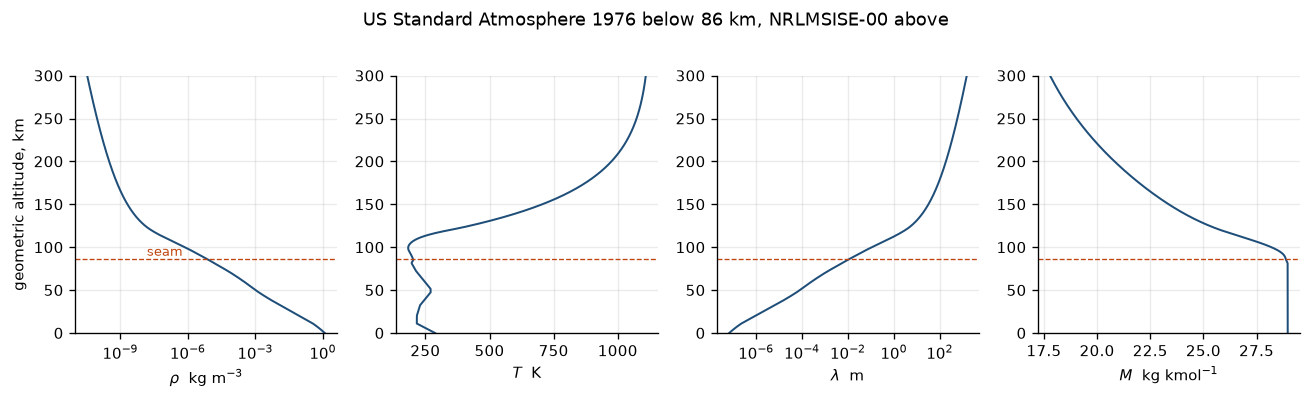

In [3]:
atmosphere = earth_atmosphere()
z = np.linspace(0.0, 300e3, 4000)
state = atmosphere.state(z)
residual = float(np.max(np.abs(state.pressure /
                               (state.density * state.gas_constant * state.temperature) - 1)))
print(f"gas-law residual over 0-300 km: {residual:.2e}")

seam = np.linspace(75e3, 92e3, 3401)
curvature = float(np.max(np.abs(np.diff(np.log(atmosphere.state(seam).density), 2))))
print(f"max |d^2 ln(rho)| across the 80-86 km seam: {curvature:.2e}")

fig, ax = plt.subplots(1, 4, figsize=(11, 3.2))
for a, values, label, scale in (
    (ax[0], state.density, r"$\rho$  kg m$^{-3}$", "log"),
    (ax[1], state.temperature, "$T$  K", "linear"),
    (ax[2], state.mean_free_path, r"$\lambda$  m", "log"),
    (ax[3], state.molar_mass, "$M$  kg kmol$^{-1}$", "linear"),
):
    a.plot(values, z / 1e3, lw=1.2, color="#1f4e79")
    a.set_xscale(scale); a.set_xlabel(label); a.set_ylim(0, 300)
    a.axhline(86, color="#c1440e", lw=0.8, ls="--")
ax[0].set_ylabel("geometric altitude, km")
ax[0].text(1e-8, 90, " seam", color="#c1440e", fontsize=8)
fig.suptitle("US Standard Atmosphere 1976 below 86 km, NRLMSISE-00 above", y=1.02)
fig.tight_layout(); plt.show()

The layered model calls into a Fortran thermosphere on every query, which is
nothing once and everything inside a right-hand side an implicit integrator
evaluates $10^5$ times. `tabulate` samples it and interpolates monotonically
on $\ln\rho$, again deriving $p$ so the gas law stays exact.

In [4]:
table = tabulate(atmosphere)
probe = np.array([1234.0, 27_777.0, 63_210.0, 84_321.0, 173_456.0, 456_789.0])
error = np.abs(table.state(probe).density / atmosphere.state(probe).density - 1)
print(f"tabulated vs layered density, off-grid: max {float(np.max(error)):.2e} relative")
print(f"above the ceiling, 1200 km: {float(table.state(1200e3).density):.3e} kg/m3 "
      f"(continued exponentially, not clamped)")

tabulated vs layered density, off-grid: max 1.82e-06 relative
above the ceiling, 1200 km: 2.068e-15 kg/m3 (continued exponentially, not clamped)


## 2. Wind, and the load case it creates

In still air a gravity-turn ascent flies at $\alpha \approx 0$ by
construction, so $q\alpha$ — the product that sizes a launch vehicle's
airframe — is identically zero and the load case does not exist. It exists
because the air moves.

`reference/ERA5` holds a year of ECMWF reanalysis on 21 pressure levels to
1 hPa, six-hourly at a quarter degree. One extracted column is *one*
atmosphere; the whole month at a site is an empirical distribution of wind
profiles, which is what a launch load Monte Carlo actually needs. Real
profiles carry the correlation between shear layers that independently
sampled envelopes do not, and it is that correlation which decides whether
two shear layers add or cancel.

In [5]:
import pathlib

from passes.atmosphere.era5 import ERA5Box

SITE = (51.09, 59.84)  # Dombarovsky
cached = sorted(pathlib.Path("../reference/ERA5").glob("*-box-*.npz"))
HAVE_ERA5 = bool(cached)
if HAVE_ERA5:
    box = ERA5Box.load(cached[0])
    column = box.column(*SITE, index=0)
    ensemble = box.ensemble(*SITE)
    print(f"{cached[0].name}: {box.shape} (time, level, lat, lon)")
    print(f"{len(ensemble)} analysis times at {SITE[0]:.2f} N {SITE[1]:.2f} E")
else:
    print("no cached ERA5 box; run passes.atmosphere.era5.extract_box first")

era5_global_native_025_2015_01-box-98643fb2d0.npz: (124, 21, 16, 16) (time, level, lat, lon)
124 analysis times at 51.09 N 59.84 E


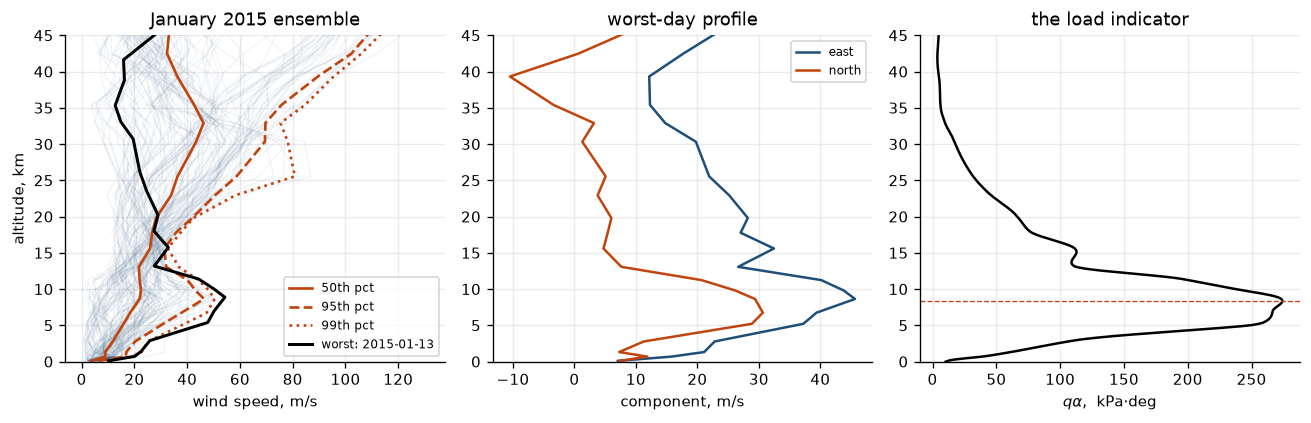

peak dynamic pressure 39.8 kPa at 15.5 km
peak q-alpha 274.1 kPa.deg at 8.3 km, alpha = 8.63 deg


In [6]:
if HAVE_ERA5:
    grid = ensemble.altitude
    speeds = ensemble.speeds()
    worst = ensemble.worst((8e3, 16e3))

    fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
    for row in speeds:
        ax[0].plot(row, grid / 1e3, color="#1f4e79", alpha=0.06, lw=0.8)
    for q, style in ((50, "-"), (95, "--"), (99, ":")):
        ax[0].plot(ensemble.percentile(q), grid / 1e3, style, lw=1.6,
                   color="#c1440e", label=f"{q}th pct")
    ax[0].plot(worst.wind_speed, worst.altitude / 1e3, lw=1.8, color="black",
               label=f"worst: {worst.epoch[:10]}")
    ax[0].set_xlabel("wind speed, m/s"); ax[0].set_ylabel("altitude, km")
    ax[0].set_title("January 2015 ensemble"); ax[0].legend(fontsize=7)

    wind = worst.wind()
    ax[1].plot(wind.velocity(grid)[:, 0], grid / 1e3, label="east", color="#1f4e79")
    ax[1].plot(wind.velocity(grid)[:, 1], grid / 1e3, label="north", color="#c1440e")
    ax[1].set_xlabel("component, m/s"); ax[1].set_title("worst-day profile")
    ax[1].legend(fontsize=7)

    # A representative vertical ascent: speed against altitude.
    climb_z = np.linspace(0.0, 45e3, 600)
    climb_v = np.interp(climb_z, [0, 5e3, 11e3, 20e3, 30e3, 45e3],
                        [30., 260., 430., 900., 1700., 2900.])
    ambient = table.state(climb_z)
    dynamic = 0.5 * np.asarray(ambient.density) * climb_v**2
    from passes.atmosphere import wind_incidence
    ground = np.stack([np.zeros_like(climb_v), np.zeros_like(climb_v), climb_v], axis=-1)
    alpha = wind_incidence(ground, wind.velocity(climb_z))
    ax[2].plot(dynamic * np.rad2deg(alpha) / 1e3, climb_z / 1e3, color="black")
    ax[2].set_xlabel(r"$q\alpha$,  kPa$\cdot$deg"); ax[2].set_title("the load indicator")
    peak = int(np.argmax(dynamic * alpha))
    ax[2].axhline(climb_z[peak] / 1e3, color="#c1440e", lw=0.8, ls="--")
    for a in ax:
        a.set_ylim(0, 45)
    fig.tight_layout(); plt.show()

    print(f"peak dynamic pressure {float(np.max(dynamic))/1e3:.1f} kPa at "
          f"{climb_z[int(np.argmax(dynamic))]/1e3:.1f} km")
    print(f"peak q-alpha {float(np.max(dynamic*np.rad2deg(alpha)))/1e3:.1f} kPa.deg at "
          f"{climb_z[peak]/1e3:.1f} km, alpha = {np.rad2deg(alpha[peak]):.2f} deg")

The two peaks are **not at the same altitude**, and that is the whole reason
$q\alpha$ is tracked separately from $q$: the structural load case sits where
the product is largest, not where either factor is.

## 3. The boundary layer

An Euler solution has no boundary layer and a panel method has no boundary
layer, so neither has friction. On a body with 305 m² of wetted area against
7.07 m² of frontal area, every count of $c_f$ is 43 counts of $C_A$.

The production method is Eckert's reference temperature. The check on it is a
**numerical solution of the compressible boundary-layer equations** — not
another correlation — with $C = \rho\mu/\rho_e\mu_e$ from Sutherland's law
rather than the Chapman–Rubesin $C = 1$ that makes the textbook version
tractable by hand.

In [7]:
from passes.aerodynamics import compressible_blasius, eckert_reference_temperature, recovery_factor
from passes.aerodynamics.friction import _sutherland

print(f"incompressible limit: c_f sqrt(Re_x) = "
      f"{compressible_blasius(0.0, wall_enthalpy_ratio=1.0).skin_friction_coefficient:.6f} "
      f"(Blasius: 0.664112)")

mach = np.array([0., 2., 5., 10., 15., 20., 25.])
t_e, r = 288.15, recovery_factor(0.71)
exact, eckert = [], []
for m in mach:
    exact.append(compressible_blasius(float(m), None).skin_friction_coefficient)
    wall = t_e * (1.0 + r * 0.2 * m**2)
    star = float(eckert_reference_temperature(t_e, float(m), wall, r))
    chapman = (t_e / star) * float(_sutherland(star) / _sutherland(t_e))
    eckert.append(0.664 * np.sqrt(chapman))
exact, eckert = np.array(exact), np.array(eckert)

print(f"\n{'M':>5} {'solved':>10} {'Eckert':>10} {'error':>9}")
for m, a, b in zip(mach, exact, eckert):
    print(f"{m:5.1f} {a:10.5f} {b:10.5f} {100*(b/a-1):+8.2f}%")

incompressible limit: c_f sqrt(Re_x) = 0.664115 (Blasius: 0.664112)



    M     solved     Eckert     error
  0.0    0.66411    0.66400    -0.02%
  2.0    0.63156    0.63069    -0.14%
  5.0    0.53323    0.52660    -1.24%
 10.0    0.41650    0.40435    -2.92%
 15.0    0.34925    0.33630    -3.71%
 20.0    0.30579    0.29322    -4.11%
 25.0    0.27505    0.26311    -4.34%


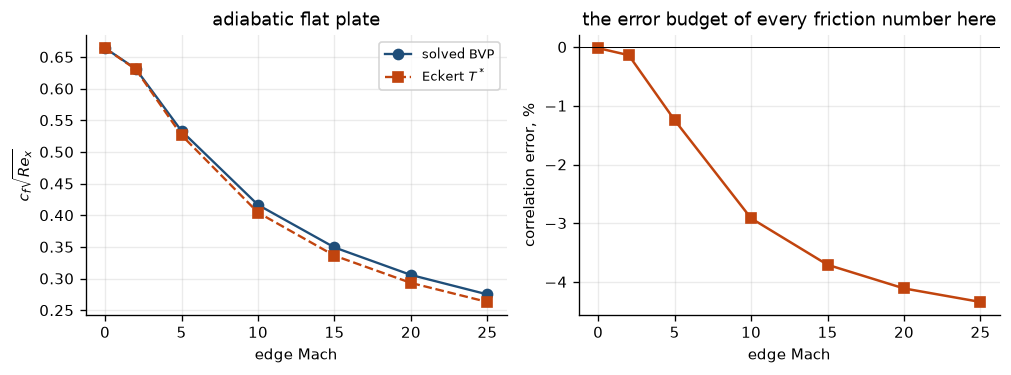

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.2))
ax[0].plot(mach, exact, "o-", lw=1.4, color="#1f4e79", label="solved BVP")
ax[0].plot(mach, eckert, "s--", lw=1.4, color="#c1440e", label="Eckert $T^*$")
ax[0].set_xlabel("edge Mach"); ax[0].set_ylabel(r"$c_f\sqrt{Re_x}$")
ax[0].set_title("adiabatic flat plate"); ax[0].legend(fontsize=8)
ax[1].plot(mach, 100 * (eckert / exact - 1), "s-", color="#c1440e")
ax[1].axhline(0, color="black", lw=0.6)
ax[1].set_xlabel("edge Mach"); ax[1].set_ylabel("correlation error, %")
ax[1].set_title("the error budget of every friction number here")
fig.tight_layout(); plt.show()

The correlation is **low everywhere and by a growing amount** — 1.2 % at Mach
5, 4.3 % at Mach 25. That is the honest error bar on the friction term, and
it is signed, so leaving it uncorrected always underpredicts drag.

The turbulent branch has no equivalent check available. Its incompressible
limit is pinned against Schultz–Grunow and its compressible behaviour is
*trusted*, not verified — which is why the two branches are separate
functions with separate docstrings.

## 4. Real gas

A perfect-gas stagnation temperature at Mach 20 is 20,000 K. Air does not
reach 20,000 K behind a Mach 20 shock; it reaches about 5,900 K, because the
oxygen dissociates and then the nitrogen, and the energy that would have gone
into translation went into breaking bonds.

The consequence that matters for a coefficient table: a calorically perfect
gas is stuck at a density ratio of 6 and a $C_{p,\max}$ of 1.839, and
equilibrium air is not.

In [9]:
from passes.aerodynamics import EquilibriumAir, perfect_gas_normal_shock

air = EquilibriumAir()
ambient = atmosphere.state(60e3)
T1, P1, a1 = (float(ambient.temperature), float(ambient.pressure),
              float(ambient.speed_of_sound))
print(f"freestream: 60 km, T = {T1:.2f} K, p = {P1:.3f} Pa, a = {a1:.1f} m/s\n")
print(f"{'M':>5} {'rho2/rho1':>11} {'perfect':>9} {'T2 K':>9} "
      f"{'Cp_max':>9} {'perfect':>9} {'gamma_eff':>10}")
records = []
for m in (3., 5., 8., 10., 15., 20., 25.):
    shock = air.normal_shock(T1, P1, m * a1)
    perfect = perfect_gas_normal_shock(shock.mach)
    records.append((m, shock, perfect))
    print(f"{m:5.1f} {shock.density_ratio:11.3f} {perfect['density_ratio']:9.3f} "
          f"{shock.temperature:9.1f} {shock.cp_max:9.4f} {perfect['cp_max']:9.4f} "
          f"{shock.effective_gamma:10.4f}")

freestream: 60 km, T = 247.02 K, p = 21.959 Pa, a = 315.1 m/s

    M   rho2/rho1   perfect      T2 K    Cp_max   perfect  gamma_eff
  3.0       3.922     3.852     651.9    1.7598    1.7554     1.3851
  5.0       5.459     4.997    1333.9    1.8245    1.8087     1.3503


  8.0       7.601     5.564    2494.1    1.8728    1.8273     1.2669
 10.0       9.760     5.713    2929.0    1.9001    1.8316     1.2059
 15.0      11.646     5.869    4870.6    1.9159    1.8359     1.1781
 20.0      14.908     5.926    5889.0    1.9340    1.8374     1.1384
 25.0      17.219     5.952    6727.2    1.9427    1.8381     1.1199


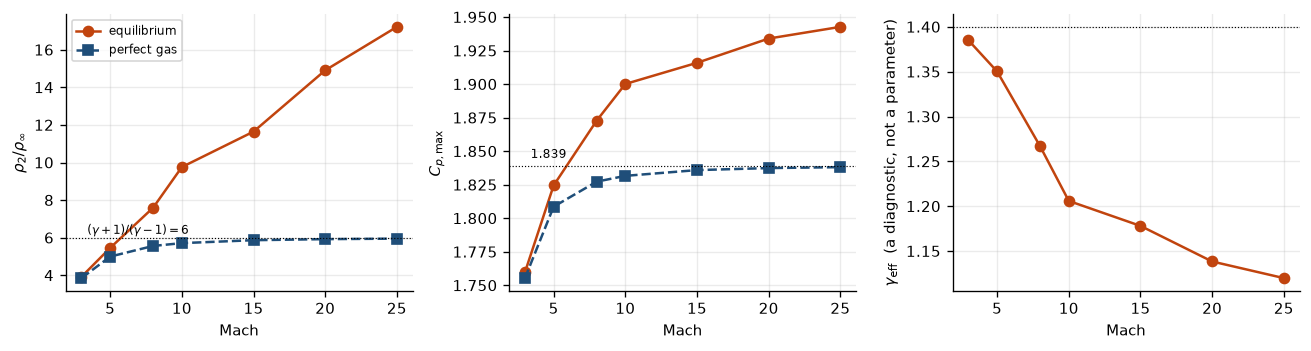

In [10]:
mm = np.array([r[0] for r in records])
fig, ax = plt.subplots(1, 3, figsize=(11, 3.0))
ax[0].plot(mm, [r[1].density_ratio for r in records], "o-", color="#c1440e", label="equilibrium")
ax[0].plot(mm, [r[2]["density_ratio"] for r in records], "s--", color="#1f4e79", label="perfect gas")
ax[0].axhline(6.0, color="black", lw=0.7, ls=":"); ax[0].text(3.4, 6.2, r"$(\gamma+1)/(\gamma-1)=6$", fontsize=7)
ax[0].set_ylabel(r"$\rho_2/\rho_\infty$"); ax[0].legend(fontsize=7)
ax[1].plot(mm, [r[1].cp_max for r in records], "o-", color="#c1440e")
ax[1].plot(mm, [r[2]["cp_max"] for r in records], "s--", color="#1f4e79")
ax[1].axhline(1.839, color="black", lw=0.7, ls=":"); ax[1].text(3.4, 1.845, "1.839", fontsize=7)
ax[1].set_ylabel(r"$C_{p,\max}$")
ax[2].plot(mm, [r[1].effective_gamma for r in records], "o-", color="#c1440e")
ax[2].axhline(1.4, color="black", lw=0.7, ls=":")
ax[2].set_ylabel(r"$\gamma_{\rm eff}$  (a diagnostic, not a parameter)")
for a in ax:
    a.set_xlabel("Mach")
fig.tight_layout(); plt.show()

$C_{p,\max}$ reaches **1.94** at Mach 25 against the perfect gas's 1.838
asymptote. Every windward panel pressure scales with it, so that is a 5.7 %
increase in axial force that the Rayleigh–Pitot relation cannot produce at any
Mach number, because its limit is 1.839 by construction — and it goes the way
that makes a perfect-gas range estimate optimistic.

## 5. Rarefied flow

Above about 90 km a molecule that leaves the vehicle does not hit another one.
There is no shock, no boundary layer and no continuum, and the Navier–Stokes
equations are not inaccurate there — they are inapplicable.

The check on the surface closure is the closed-form free-molecular sphere
drag. It is a real check on both branches, because the pressure branch
integrates to exactly 1 and the shear branch to exactly 1 for a hyperthermal
total of 2: **a pressure-only implementation would be short by half** and
would fail at every speed ratio.

In [11]:
from passes.aerodynamics import FreeMolecularSolver, sine_squared_bridge, sphere_free_molecular_drag
from passes.aerodynamics.panels import PanelModel


def unit_sphere(n_theta=300, n_phi=150):
    theta = np.linspace(0.0, np.pi, n_theta + 1)
    phi = np.linspace(0.0, 2.0 * np.pi, n_phi + 1)
    c, n, a = [], [], []
    for i in range(n_theta):
        for j in range(n_phi):
            t, p = 0.5 * (theta[i] + theta[i+1]), 0.5 * (phi[j] + phi[j+1])
            u = np.array([np.cos(t), np.sin(t) * np.cos(p), np.sin(t) * np.sin(p)])
            c.append(u); n.append(u)
            a.append((np.cos(theta[i]) - np.cos(theta[i+1])) * (phi[j+1] - phi[j]))
    return PanelModel(np.array(c), np.array(n), np.array(a))


class _Wrap:
    def __init__(self, m): self._m = m
    def panel_model(self, rp): return self._m


solver = FreeMolecularSolver(_Wrap(unit_sphere()), np.pi, 2.0, wall_temperature=300.0)
print(f"{'S':>7} {'panel integration':>18} {'closed form':>13} {'rel err':>10}")
for S in (0.5, 1.0, 2.0, 5.0, 10.0, 21.0, 50.0):
    computed = solver.solve(S / np.sqrt(0.7), 0.0, temperature=250.0).axial
    exact = sphere_free_molecular_drag(S, 300.0 / 250.0)
    print(f"{S:7.2f} {computed:18.6f} {exact:13.6f} {computed/exact-1:+10.2e}")
print(f"\nhyperthermal limit, S -> inf: {sphere_free_molecular_drag(1e4, 0.0):.7f}")

      S  panel integration   closed form    rel err


   0.50           8.902569      8.902530  +4.43e-06
   1.00           4.866554      4.866531  +4.60e-06
   2.00           3.116051      3.116036  +4.88e-06
   5.00           2.338095      2.338083  +4.92e-06
  10.00           2.149402      2.149392  +4.80e-06
  21.00           2.066181      2.066171  +4.70e-06
  50.00           2.026698      2.026688  +4.63e-06

hyperthermal limit, S -> inf: 2.0000000


Between $Kn = 10^{-3}$ and $10$ neither limit holds and **there is no theory,
only correlation**. The Wilmoth–Blanchard bridge below is the weakest link in
this pipeline: it interpolates between two things that are each defensible and
asserts nothing of its own. Direct simulation Monte Carlo is what actually
resolves this band, and it is not here.

## 6. The exact answer: Taylor–Maccoll

Supersonic flow over a sharp cone is one of very few compressible flows with
an exact solution — exact in the strong sense: no linearisation, no thin-body
assumption. That makes it the right instrument for validating a CFD pipeline,
because a finite-volume Euler solver and a shooting method on a second-order
ODE share no code, no discretisation and no formulation.

Three checks that need no external tables:

In [12]:
from passes.aerodynamics import mach_angle, maximum_cone_angle, solve_cone, wedge_shock_angle
from passes.aerodynamics import rayleigh_pitot_cp_max

print("1. a cone's shock is always weaker than a wedge's at the same angle")
print(f"{'M':>5} {'theta_c':>9} {'beta_cone':>11} {'beta_wedge':>11} {'Cp':>9} {'Cp_newton':>10}")
for m, deg in ((2., 10.), (3., 15.), (5., 25.), (10., 20.), (20., 30.)):
    t = np.deg2rad(deg); s = solve_cone(m, t)
    print(f"{m:5.1f} {deg:9.1f} {np.rad2deg(s.shock_angle):11.4f} "
          f"{np.rad2deg(wedge_shock_angle(m, t)):11.4f} {s.pressure_coefficient:9.5f} "
          f"{rayleigh_pitot_cp_max(m)*np.sin(t)**2:10.5f}")

print("\n2. as the cone vanishes the shock becomes the Mach wave")
print(f"   Mach angle at M=5: {np.rad2deg(mach_angle(5.)):.6f} deg")
for deg in (2., 0.5, 0.05):
    print(f"   theta_c = {deg:5.2f} deg -> beta = "
          f"{np.rad2deg(solve_cone(5., np.deg2rad(deg)).shock_angle):.6f} deg")

print("\n3. the detachment limit is the classical 57.5 deg for gamma = 1.4")
for m in (2., 5., 10., 20., 40.):
    angle, beta = maximum_cone_angle(m)
    print(f"   M = {m:5.1f}: max attached cone {np.rad2deg(angle):7.3f} deg "
          f"at beta = {np.rad2deg(beta):6.3f} deg")

1. a cone's shock is always weaker than a wedge's at the same angle
    M   theta_c   beta_cone  beta_wedge        Cp  Cp_newton
  2.0      10.0     31.2061     39.3139   0.10447    0.04997
  3.0      15.0     25.2589     32.2404   0.17311    0.11761
  5.0      25.0     30.1577     35.7794   0.39101    0.32306
 10.0      20.0     22.7454     25.8178   0.24894    0.21426
 20.0      30.0     33.3362     37.5417   0.52520    0.45936

2. as the cone vanishes the shock becomes the Mach wave
   Mach angle at M=5: 11.536959 deg
   theta_c =  2.00 deg -> beta = 11.564232 deg


   theta_c =  0.50 deg -> beta = 11.537056 deg
   theta_c =  0.05 deg -> beta = 11.536959 deg

3. the detachment limit is the classical 57.5 deg for gamma = 1.4
   M =   2.0: max attached cone  40.688 deg at beta = 69.417 deg
   M =   5.0: max attached cone  54.482 deg at beta = 72.910 deg
   M =  10.0: max attached cone  56.859 deg at beta = 73.768 deg
   M =  20.0: max attached cone  57.478 deg at beta = 74.002 deg
   M =  40.0: max attached cone  57.634 deg at beta = 74.062 deg


The Newtonian column is the panel method's closure, and it is **low on every
row**. Impact theory underpredicts a cone by 15–25 % at moderate supersonic
speeds and converges toward it at high Mach; that is the shape of the panel
method's error, measured rather than asserted.

## 7. Closing the transonic gap

The panel method's floor is Mach 1.2 and a launch vehicle sees its highest
dynamic pressure below it — the part of the curve that sizes the structure was
the part not covered. Axisymmetric Euler closes it, because a body of
revolution at zero incidence is a two-dimensional problem.

The pipeline is gmsh → SU2 → surface-pressure integration. Forces are **not**
read from SU2's own output: for an axisymmetric case that depends on a
reference-area convention which has changed between releases. Instead the wall
pressure is integrated here, using an identity that removes normals, arc
lengths and node ordering from the problem entirely:

$$\hat n_x \, \mathrm{d}S = -\pi\,\mathrm{d}(r^2)
\qquad\Longrightarrow\qquad
F_x = \pi\!\!\int_{\rm nose}^{\rm base}\!\!(p - p_\infty)\,\mathrm{d}(r^2)$$

The validation case is a 15° cone at Mach 3, run through the *same* meshing
and solver path as a production case.

In [13]:
import time

from passes.aerodynamics.cfd import (
    DomainSizing, axisymmetric_domain, cone_profile, grid_convergence, run_su2,
    SU2Settings, find_su2,
)

try:
    print("SU2:", find_su2())
    HAVE_SU2 = True
except FileNotFoundError as error:
    print(error)
    HAVE_SU2 = False

MACH, ANGLE = 3.0, 15.0
profile = cone_profile(np.deg2rad(ANGLE), length=1.0)
exact = solve_cone(MACH, np.deg2rad(ANGLE))
print(f"\nexact Taylor-Maccoll: Cp = {exact.pressure_coefficient:.6f}, "
      f"shock angle = {np.rad2deg(exact.shock_angle):.4f} deg")

SU2: /config/miniconda3/envs/su2/bin/SU2_CFD

exact Taylor-Maccoll: Cp = 0.173108, shock angle = 25.2589 deg


In [14]:
GRID_DIR = pathlib.Path("../results/aero/cfd-validation")
rows = []
if HAVE_SU2:
    settings = SU2Settings(iterations=12000, force_tolerance=1e-5, force_window=200,
                           extra={"LIMITER_ITER": "3000"})
    for factor in (2.0, 1.41, 1.0, 0.71):
        mesh = axisymmetric_domain(profile, GRID_DIR / f"cone-{factor}.su2",
                                   mach=MACH, sizing=DomainSizing().scaled(factor))
        started = time.time()
        result = run_su2(mesh, profile, MACH, GRID_DIR / f"run-{factor}", settings)
        rows.append((mesh.n_elements, mesh.representative_size,
                     result.forebody_axial, result.base_axial))
        print(f"factor {factor:<5g} N = {mesh.n_elements:7d}  "
              f"C_A = {result.forebody_axial:.6f}  "
              f"err = {100*(result.forebody_axial/exact.pressure_coefficient-1):+7.3f}%  "
              f"({time.time()-started:5.1f} s)", flush=True)

factor 2     N =    5389  C_A = 0.165600  err =  -4.337%  ( 21.9 s)


factor 1.41  N =   11058  C_A = 0.171278  err =  -1.057%  ( 46.4 s)


factor 1     N =   22413  C_A = 0.172749  err =  -0.208%  (101.9 s)


factor 0.71  N =   44551  C_A = 0.172967  err =  -0.082%  (223.8 s)


Richardson extrapolation on the three finest meshes
  p = 5.375, extrapolated 0.173008, finest 0.172967 (-0.02 %), GCI 0.03 %
  extrapolated vs exact Taylor-Maccoll: -0.058%
  finest mesh vs exact:                 -0.082%

  the same fit on the three COARSEST meshes: p = 3.735, extrapolated 0.173285 (+0.10%)


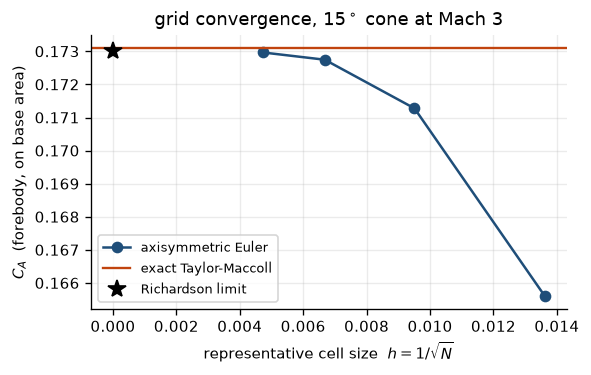

In [15]:
if rows:
    spacing = np.array([r[1] for r in rows])
    values = np.array([r[2] for r in rows])
    # `rows` is coarsest-first, so the three finest are the last three.
    study = grid_convergence(spacing[1:], values[1:])
    print("Richardson extrapolation on the three finest meshes")
    print(" ", study.summary())
    print(f"  extrapolated vs exact Taylor-Maccoll: "
          f"{100*(study.extrapolated/exact.pressure_coefficient-1):+.3f}%")
    print(f"  finest mesh vs exact:                 "
          f"{100*(values[-1]/exact.pressure_coefficient-1):+.3f}%")
    coarse = grid_convergence(spacing[:3], values[:3])
    print(f"\n  the same fit on the three COARSEST meshes: p = "
          f"{coarse.observed_order:.3f}, extrapolated {coarse.extrapolated:.6f} "
          f"({100*(coarse.extrapolated/exact.pressure_coefficient-1):+.2f}%)")

    fig, ax = plt.subplots(figsize=(5, 3.2))
    ax.plot(spacing, values, "o-", color="#1f4e79", label="axisymmetric Euler")
    ax.axhline(exact.pressure_coefficient, color="#c1440e", lw=1.4,
               label="exact Taylor-Maccoll")
    ax.plot(0.0, study.extrapolated, "k*", ms=11, label="Richardson limit")
    ax.set_xlabel(r"representative cell size  $h = 1/\sqrt{N}$")
    ax.set_ylabel("$C_A$  (forebody, on base area)")
    ax.set_title(f"grid convergence, {ANGLE:.0f}$^\\circ$ cone at Mach {MACH:g}")
    ax.legend(fontsize=8); fig.tight_layout(); plt.show()

Two things the study says that a single number would not.

**The base contribution is not converging.** It wanders non-monotonically with
refinement, and it should: the real base pressure is set by a separated shear
layer that the Euler equations do not describe. That is why `SU2Result` reports
`forebody_axial` and `base_axial` separately instead of one total — so a caller
can replace it, and can see how much is at stake.

**The extrapolated value is robust; the observed order is not.** Both fits —
the three finest and the three coarsest — land within 0.1 % of the exact
answer, but they report orders of 5.4 and 3.7. Neither is the formal order of
the scheme, and neither should be: a captured shock is first order however the
interior is discretised, and once the two finest values agree to within
iterative-convergence noise the exponent is fitted to that noise. Read the
value and the GCI; treat $p$ as a diagnostic that the fit is in a sensible
regime, not as a measurement of the discretisation.

**One defect found here was worth the whole exercise.** The base corner is a
single node shared by two faces, and its pressure belongs to neither: on this
cone it came back at $C_p = +0.45$ where the body is at $+0.17$. Left in, it
lands at the largest radius, where the area weight $\mathrm{d}(r^2)$ is
greatest, and it simultaneously poisoned the base integral and dropped the
closing 1.5 % of the lateral one. The error looked like mesh resolution —
convergence at an apparent order of 0.57 — right up until it was found.

## 8. The assembled pipeline

`PatchedSolver` runs each theory where it is valid and reports which one it
used. The altitude may be a **schedule** $z(M)$ rather than a constant, which
is how launch-vehicle coefficient tables are actually built: along the
trajectory the vehicle will fly, not over a rectangle it will not.

In [16]:
from passes.aerodynamics import (
    BoundaryLayer, PanelSolver, PatchedSolver, RadiativeEquilibriumWall, SkinFrictionModel,
)
from passes.geometry import load_stl

mesh = load_stl("../data/vehicles/rs28/rs28-configuration-full-stack.stl", name="stack")
AREA, LENGTH = 7.0686, 3.0

def ascent(m: float) -> float:
    return float(np.interp(m, [0.5, 1.2, 2, 3, 5, 8, 12, 20, 25],
                              [5e3, 10e3, 16e3, 24e3, 38e3, 60e3, 85e3, 120e3, 150e3]))

pipeline = PatchedSolver(
    panel=PanelSolver(mesh, AREA, LENGTH),
    reference_area=AREA, reference_length=LENGTH,
    altitude=ascent,
    friction=SkinFrictionModel(mesh, AREA, LENGTH,
                               BoundaryLayer(wall=RadiativeEquilibriumWall())),
    free_molecular=FreeMolecularSolver(mesh, AREA, LENGTH),
    real_gas=EquilibriumAir(),
    atmosphere=table,
)
print(f"mesh: {mesh.n_faces} faces, {mesh.wetted_area:.1f} m2 wetted "
      f"({mesh.wetted_area/AREA:.0f}x the frontal area)")

mesh: 6311 faces, 304.6 m2 wetted (43x the frontal area)


In [17]:
sweep = np.array([1.6, 2., 3., 5., 8., 12., 16., 20., 25.])
print(f"{'M':>5} {'z km':>7} {'Re':>10} {'chi':>9} {'f_val':>7} {'bridge':>7} "
      f"{'C_A':>8} {'invisc':>8} {'fric':>8} {'free-mol':>9}")
history = []
for m in sweep:
    d = pipeline.diagnostics(float(m))
    parts = pipeline.components(float(m), 0.0)
    total = pipeline.solve(float(m), 0.0)
    history.append((d, parts, total))
    print(f"{m:5.1f} {d['altitude']/1e3:7.1f} {d['reynolds']:10.2e} "
          f"{d['viscous_interaction']:9.2f} {d['friction_validity']:7.3f} "
          f"{d['bridge']:7.3f} {total.axial:8.4f} {parts['inviscid'].axial:8.4f} "
          f"{parts['friction'].axial:8.4f} {parts['free_molecular'].axial:9.4f}")

    M    z km         Re       chi   f_val  bridge      C_A   invisc     fric  free-mol


  1.6    13.0   2.66e+07      0.00   1.000   0.000   1.3357   1.2854   0.0503    0.0000


  2.0    16.0   2.07e+07      0.00   1.000   0.000   1.1855   1.1357   0.0498    0.0000


  3.0    24.0   8.72e+06      0.01   1.000   0.000   1.0418   0.9885   0.0533    0.0000


  5.0    38.0   1.61e+06      0.10   1.000   0.000   0.9794   0.9117   0.0677    0.0000


  8.0    60.0   1.48e+05      1.33   0.791   0.000   0.9829   0.9062   0.0767    0.0000


 12.0    85.0   6.63e+03     21.22   0.000   0.037   1.0784   0.9143   0.0000    5.3238


 16.0   102.5   4.93e+02    184.48   0.000   0.404   2.4678   0.9137   0.0000    4.7609


 20.0   120.0   2.67e+01   1547.10   0.000   0.859   3.9049   0.9275   0.0000    4.3954
 25.0   150.0   2.73e+00   9456.60   0.000   1.000   4.1127   0.0000   0.0000    4.1127


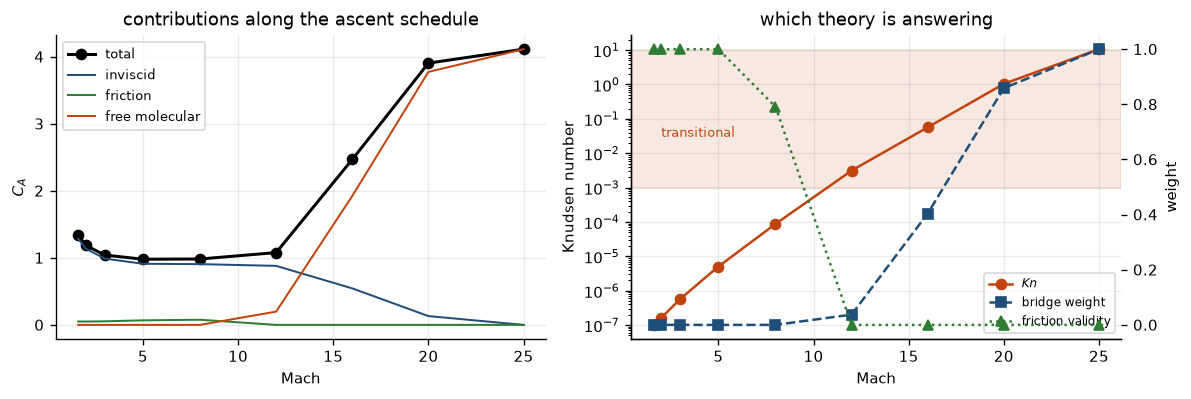

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
inviscid = np.array([h[1]["inviscid"].axial for h in history])
friction = np.array([h[1]["friction"].axial for h in history])
freemol = np.array([h[1]["free_molecular"].axial for h in history])
bridge = np.array([h[0]["bridge"] for h in history])
total = np.array([h[2].axial for h in history])

ax[0].plot(sweep, total, "k-o", lw=1.8, label="total")
ax[0].plot(sweep, inviscid * (1 - bridge), lw=1.2, color="#1f4e79", label="inviscid")
ax[0].plot(sweep, friction * (1 - bridge), lw=1.2, color="#2e7d32", label="friction")
ax[0].plot(sweep, freemol * bridge, lw=1.2, color="#c1440e", label="free molecular")
ax[0].set_xlabel("Mach"); ax[0].set_ylabel("$C_A$"); ax[0].legend(fontsize=8)
ax[0].set_title("contributions along the ascent schedule")

ax[1].semilogy(sweep, [h[0]["knudsen"] for h in history], "o-", color="#c1440e",
               label="$Kn$")
ax[1].axhspan(1e-3, 10, alpha=0.12, color="#c1440e")
ax[1].text(2, 3e-2, "transitional", fontsize=8, color="#c1440e")
axb = ax[1].twinx()
axb.plot(sweep, bridge, "s--", color="#1f4e79", label="bridge weight")
axb.plot(sweep, [h[0]["friction_validity"] for h in history], "^:", color="#2e7d32",
         label="friction validity")
axb.set_ylabel("weight"); axb.grid(False)
ax[1].set_xlabel("Mach"); ax[1].set_ylabel("Knudsen number")
ax[1].set_title("which theory is answering")
lines = ax[1].get_lines() + axb.get_lines()
ax[1].legend(lines, [ln.get_label() for ln in lines], fontsize=7, loc="lower right")
fig.tight_layout(); plt.show()

### What the diagnostics are for

The `friction_validity` column is a **validity gate, not a model**. The
reference-temperature method is a boundary-layer method, and
$\bar\chi = M^3/\sqrt{Re_L}$ measures whether there is a boundary layer:
$\bar\chi \gtrsim 1$ means the layer is as thick as the body. Without the gate
the correlation returns a skin-friction contribution of **6.0** to $C_A$ at
Mach 20 and 120 km against an inviscid 0.93 — not a large correction but a
meaningless number, since $Re_L$ there is of order $10^3$.

Fading it out does not *solve* that regime. What actually happens between
$\bar\chi \sim 1$ and free-molecular flow is merged-layer, strong-viscous-
interaction hypersonics, and nothing in this package computes it. The Knudsen
bridge carries the answer across, and the bridge is an interpolation.
**Coefficients reported where `friction_validity` is between 0 and 1 while
`bridge` is still small are the least trustworthy this pipeline produces** —
which is exactly what `diagnostics` exists to make visible.

## 9. Into the trajectory

`FlightConfiguration.drag_area` was a hand-set constant. On this vehicle $C_A$
runs from 1.62 at Mach 1.2 to 0.87 at Mach 25, so a single number is wrong by
a factor of two somewhere on every ascent. Setting `aero_table` reads it from
the curve — and, because that needs a speed of sound, selects the layered
atmosphere over the exponential one.

In [19]:
from passes.aerodynamics import AeroTable
from passes.flight.simulator import FlightConfiguration, FlightSimulator

alphas = np.array([0.0])
axial = np.array([[pipeline.solve(float(m), 0.0).axial] for m in sweep])
aero = AeroTable("rs28-full-stack", sweep, alphas, axial,
                 np.zeros_like(axial), np.zeros_like(axial),
                 reference_area=AREA, reference_length=LENGTH, solver=pipeline.name)

print(f"{'Mach':>6} {'C_A':>8} {'C_D A, m2':>11}")
for m in (1.6, 3.0, 8.0, 20.0, 30.0):
    print(f"{m:6.1f} {aero.at(m, 0.0).axial:8.4f} {aero.drag_area(m):11.4f}")
print("\n(Mach 30 is clamped to the Mach 25 value, not extrapolated off the end "
      "of a curve that is asymptotic anyway)")

simulator = FlightSimulator(FlightConfiguration(aero_table=aero, length=35.4))
print(f"\natmosphere selected by the table: {simulator._atmosphere.name}")

  Mach      C_A   C_D A, m2
   1.6   1.3357      9.4414
   3.0   1.0418      7.3639
   8.0   0.9829      6.9476
  20.0   3.9049     27.6022
  30.0   4.1127     29.0712

(Mach 30 is clamped to the Mach 25 value, not extrapolated off the end of a curve that is asymptotic anyway)

atmosphere selected by the table: US Standard Atmosphere 1976 / NRLMSISE-00 (moderate activity) (tabulated)


## What is not covered

Stated here rather than left to be discovered:

1. **Normal force and pitching moment below Mach 1.2.** The axisymmetric
   formulation is a zero-incidence method — that is why the transonic band is
   affordable at all — and no post-processing of an axisymmetric solution
   recovers a normal force. `EulerSolver.solve` refuses a non-zero incidence
   rather than returning something plausible. Three-dimensional cases are the
   route, and they are the week-long runs the checkpointing framework exists
   for.
2. **The merged-layer regime**, as above.
3. **Base drag.** Reported separately, never folded in, because an Euler base
   pressure is not a base pressure.
4. **Turbulent compressible friction**, trusted rather than verified.
5. **Argon**, absent from the equilibrium air mixture: 0.93 % by mole and
   inert, worth 0.3 % on molar mass. Noted because the mixture should be
   visible, not because it matters.